In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [ ]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.isnull()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False


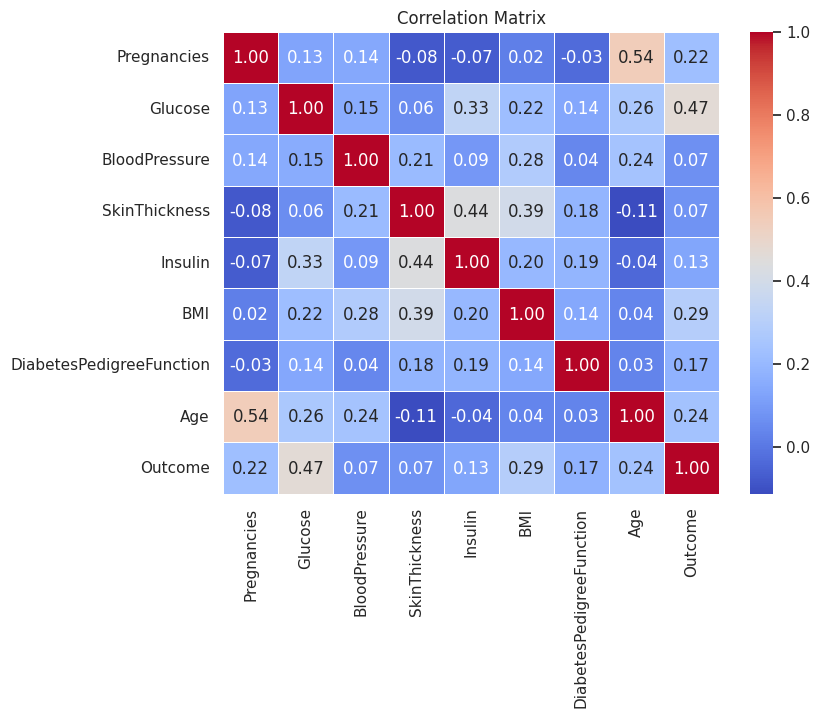

In [ ]:
plt.figure(figsize=(8,6))
correlation=df.corr()
sns.heatmap(correlation,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
zero_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts=(df[zero_columns]==0).sum()
print("Zero columns")
print(zero_counts)

Zero columns
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
df_clean=df.copy()
df_clean[zero_columns]==df_clean[zero_columns].replace(0,np.nan)
print("Missing values after replacing zeros:")
print(df_clean.isnull().sum())

Missing values after replacing zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
for col in zero_columns:
  df_clean[col]=df_clean[col].fillna(df_clean[col].median())
  print("Missing values after median imputation:")
  print(df_clean.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Missing values after median imp

In [ ]:
X=df_clean.drop("Outcome",axis=1)
y=df_clean["Outcome"]

print("X shape:",X.shape)
print("Y shape:",y.shape)

X shape: (768, 8)
Y shape: (768,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training samples",X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples 614
Testing samples: 154


In [ ]:
print("Training distribution")
print(y_train.value_counts(normalize=True))

print("Testing distribution")
print(y_test.value_counts(normalize=True))

Training distribution
Outcome
0    0.653094
1    0.346906
Name: proportion, dtype: float64
Testing distribution
Outcome
0    0.642857
1    0.357143
Name: proportion, dtype: float64


In [ ]:
scalar=StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [ ]:
scalar.fit_transform(X_test)

array([[ 0.49124165, -0.72667791, -0.44147615, ...,  0.23374785,
        -0.17094071,  0.66661154],
       [-0.63368347, -0.28534901,  0.31890843, ...,  0.43537945,
        -1.08608042, -1.07335756],
       [-0.63368347, -0.41144298, -0.17310512, ..., -0.14579397,
        -1.05362866, -1.07335756],
       ...,
       [ 1.05370422, -0.82124838,  0.18472291, ...,  0.56584695,
         0.00754398,  1.77386461],
       [-0.63368347,  0.78644972,  0.09526591, ..., -0.47789306,
        -0.47274211, -0.44064153],
       [ 1.05370422, -1.48324172,  0.09526591, ...,  0.38793672,
         0.72148276,  0.35025352]])

In [ ]:
scalar.transform(X_test)

array([[ 0.49124165, -0.72667791, -0.44147615, ...,  0.23374785,
        -0.17094071,  0.66661154],
       [-0.63368347, -0.28534901,  0.31890843, ...,  0.43537945,
        -1.08608042, -1.07335756],
       [-0.63368347, -0.41144298, -0.17310512, ..., -0.14579397,
        -1.05362866, -1.07335756],
       ...,
       [ 1.05370422, -0.82124838,  0.18472291, ...,  0.56584695,
         0.00754398,  1.77386461],
       [-0.63368347,  0.78644972,  0.09526591, ..., -0.47789306,
        -0.47274211, -0.44064153],
       [ 1.05370422, -1.48324172,  0.09526591, ...,  0.38793672,
         0.72148276,  0.35025352]])

In [ ]:
comparision=pd.DataFrame({
    "Original mean":X_train.mean(),
    "Original std":X_train.std(),
    "Scaled mean":X_train_scaled.mean(),
    "Scaled std":X_train_scaled.std()
})


In [ ]:
K=5

In [ ]:
knn=KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred=knn.predict(X_test_scaled)
print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0]


In [ ]:
y_prob=knn.predict(X_test_scaled)

print(y_prob[:20])

[0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0]


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:4f}")
precision=precision_score(y_test,y_pred)
print(f"Precision:{precision:4f}")
recall=recall_score(y_test,y_pred)
print(f"Recall:{recall:4f}")
f1=f1_score(y_test,y_pred)
print(f"F1 score:{f1:4f}")

Accuracy:0.694805
Precision:0.583333
Recall:0.509091
F1 score:0.543689


In [ ]:
print(classification_report(y_test,y_pred,target_names=["No Diabetes","Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.75      0.80      0.77        99
    Diabetes       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154



In [ ]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[79 20]
 [27 28]]


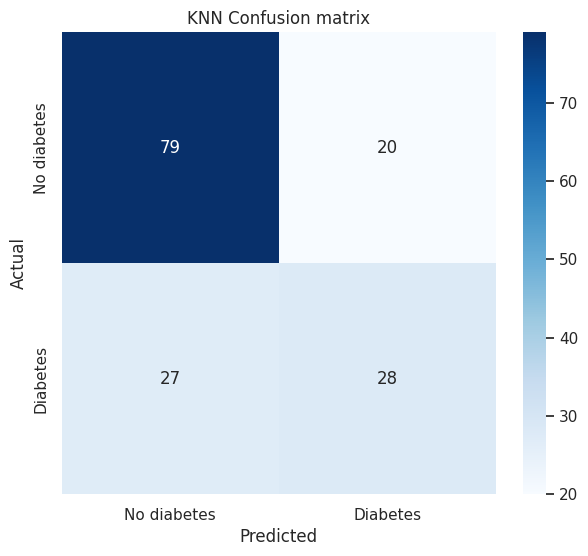

In [ ]:
plt.figure(figsize=(7,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No diabetes","Diabetes"],yticklabels=["No diabetes","Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion matrix")
plt.show()


In [ ]:
k_values=range(1,31)
train_accuracy=[]
test_accuracy=[]
for k in k_values:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_scaled,y_train)
  train_accuracy.append(model.score(X_train_scaled,y_train))
  test_accuracy.append(model.score(X_test_scaled,y_test))


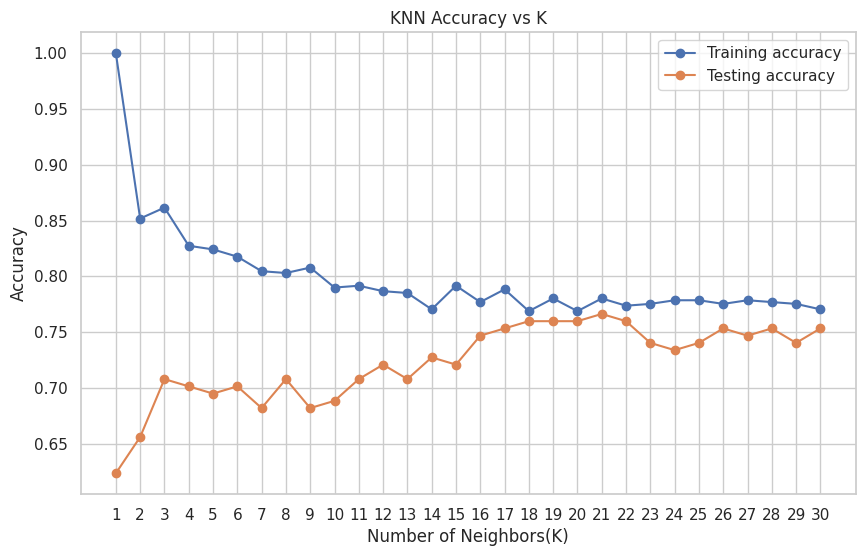

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_values,train_accuracy,marker="o",label="Training accuracy")
plt.plot(k_values,test_accuracy,marker="o",label="Testing accuracy")
plt.xlabel("Number of Neighbors(K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_values)
plt.legend()

In [ ]:
best_k_acccuracy=k_values[np.argmax(test_accuracy)]
best_accuracy=max(test_accuracy)
print("Best K:",best_k_acccuracy)
print("Best Accuracy:",best_accuracy)

Best K: 21
Best Accuracy: 0.7662337662337663


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = []

for k in range(1, 31):

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        model, X_train_scaled, y_train, cv=cv, scoring="accuracy"
    )

    cv_scores.append(scores.mean())

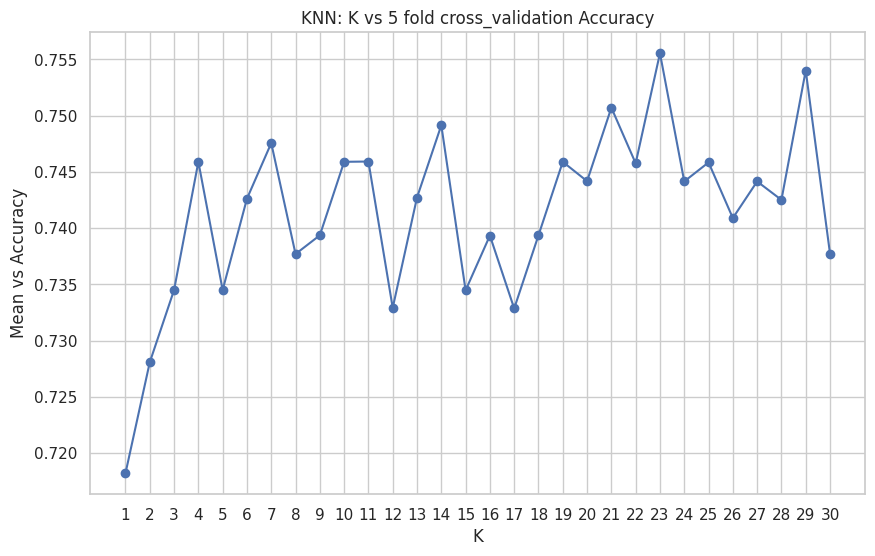

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1, 31), cv_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Mean vs Accuracy")
plt.title("KNN: K vs 5 fold cross_validation Accuracy")
plt.xticks(range(1, 31))
plt.show()

In [ ]:
best_k_cv=np.argmax(cv_scores)+1
print("Best K based on cross validation:",best_k_cv)
print("Best cv Accuracy:",max(cv_scores))

Best K based on cross validation: 23
Best cv Accuracy: 0.7555526176626123


In [ ]:
param_grid={
    "n_neighbors":list(range(3,31,2)),"weights":["uniform","distance"],
    "metric":["euclidian","manhattan",""]
}